In [2]:
import sys
sys.path.insert(0, r"D:\SEMESTER 07\Digital Image Processing\project\PRODEXA")

In [3]:
import os
import sys
import json
import random
import cv2
import matplotlib.pyplot as plt
from src.preprocessing import stratified_sample
from collections import Counter

In [4]:
sys.path.append(os.path.abspath(os.path.join("..")))


In [5]:
from src.preprocessing import (
    resize_image, remove_noise, normalize_lighting,
    preprocess_image, stratified_sample, batch_preprocess
)

In [6]:
RAW_DIR = "../data/raw"
TRAIN_DIR = os.path.join(RAW_DIR, "train2019")
PROCESSED_DIR = "../data/processed"
os.makedirs(PROCESSED_DIR, exist_ok=True)

In [7]:
TRAIN_ANNOTATIONS = os.path.join(RAW_DIR, "instances_train2019.json")

sample_records = stratified_sample(TRAIN_ANNOTATIONS, images_per_category=150, seed= 42)

print(f"Total sampled images: {len(sample_records)}")

counts = Counter(r["supercategory"] for r in sample_records)
for sc, count in sorted(counts.items()):
    print(f"{sc}: {count}")

Total sampled images: 2550
alcohol: 150
candy: 150
canned_food: 150
chocolate: 150
dessert: 150
dried_food: 150
dried_fruit: 150
drink: 150
gum: 150
instant_drink: 150
instant_noodles: 150
milk: 150
personal_hygiene: 150
puffed_food: 150
seasoner: 150
stationery: 150
tissue: 150


In [8]:
manifest_path = "../data/dataset_subset.txt"

with open(manifest_path, "w") as f:
    for r in sample_records:
        f.write(f"{r['filename']}\t{r['supercategory']}\t{r['category_name']}\n")

In [9]:
sample_filename = sample_records[0]["filename"]
sample_path = os.path.join(TRAIN_DIR, sample_filename)

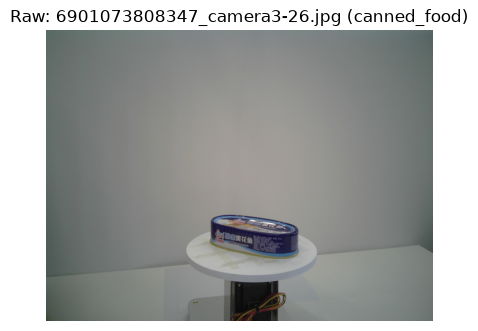

In [10]:
img = cv2.imread(sample_path)
plt.figure(figsize=(5, 5))
plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
plt.title(f"Raw: {sample_filename} ({sample_records[0]['supercategory']})")
plt.axis("off")
plt.show()

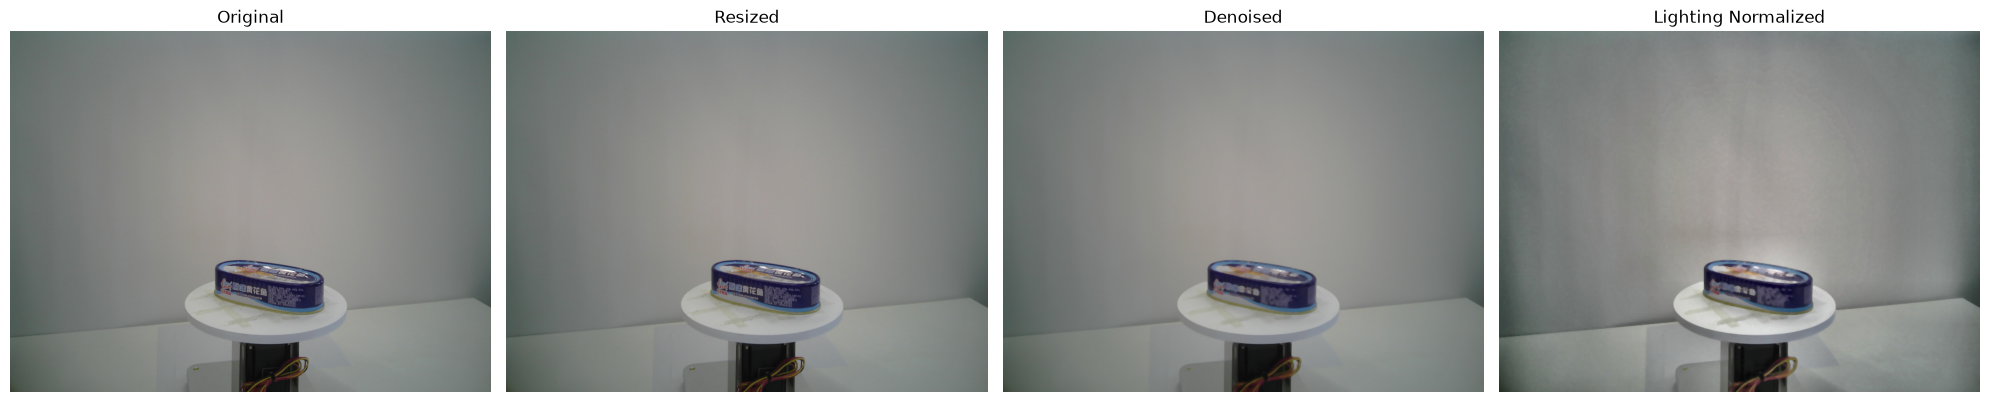

In [11]:
resized = resize_image(img)
denoised = remove_noise(resized, method="median")
normalized = normalize_lighting(denoised)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
titles = ["Original", "Resized", "Denoised", "Lighting Normalized"]
images = [img, resized, denoised, normalized]

for ax, title, im in zip(axes, titles, images):
    ax.imshow(cv2.cvtColor(im, cv2.COLOR_BGR2RGB))
    ax.set_title(title)
    ax.axis("off")
plt.tight_layout()
plt.show()

In [13]:
sample_filenames = [r["filename"] for r in sample_records]
success, total = batch_preprocess(sample_filenames, TRAIN_DIR, PROCESSED_DIR)
print(f"Processed {success}/{total} images -> {PROCESSED_DIR}")

Processed 2550/2550 images -> ../data/processed


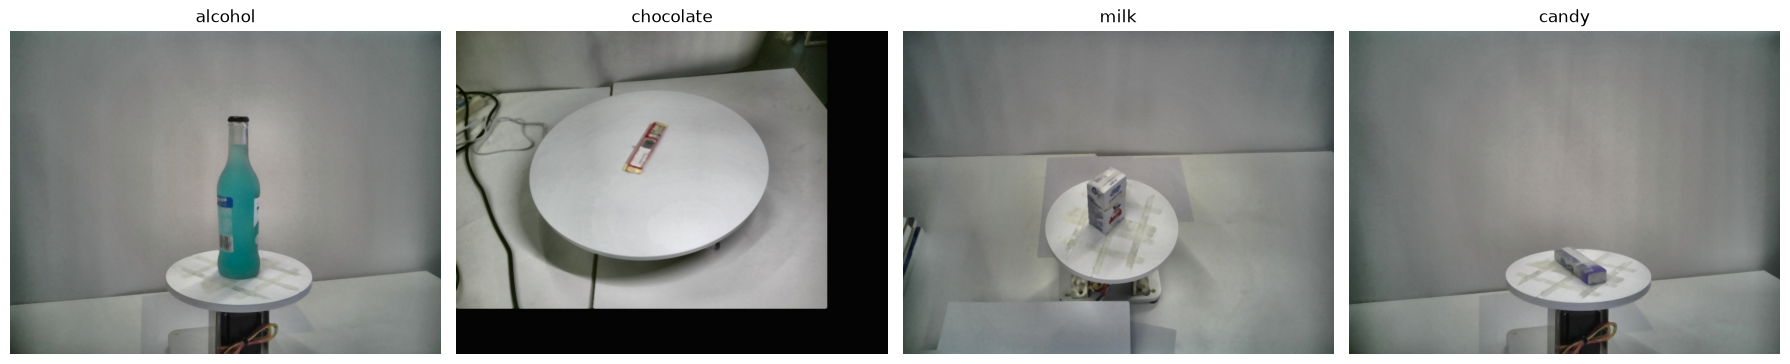

In [14]:
random.seed(1)
check_samples = random.sample(sample_records, 4)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
for ax, record in zip(axes, check_samples):
    processed_path = os.path.join(PROCESSED_DIR, record["filename"])
    img_check = cv2.imread(processed_path)
    ax.imshow(cv2.cvtColor(img_check, cv2.COLOR_BGR2RGB))
    ax.set_title(record["supercategory"])
    ax.axis("off")

plt.tight_layout()
plt.show()